# DINO Attention Maps: Unsupervised Object Discovery

Author: Aadarsha Gopala Reddy (a.gopalareddy@wustl.edu)

Papers: 

- Caron, M., Touvron, H., Misra, I., Jégou, H., Mairal, J., Bojanowski, P., & Joulin, A. (2021). Emerging Properties in Self-Supervised Vision Transformers (No. arXiv:2104.14294). arXiv. https://doi.org/10.48550/arXiv.2104.14294

- Abnar, S., & Zuidema, W. (2020). Quantifying Attention Flow in Transformers (No. arXiv:2005.00928). arXiv. https://doi.org/10.48550/arXiv.2005.00928

- Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2021). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale (No. arXiv:2010.11929). arXiv. https://doi.org/10.48550/arXiv.2010.11929

Summary: This notebook demonstrates how Vision Transformer (ViT) attention from a self-supervised DINO model can localize salient objects without labels. This extracts per-layer, per-head self-attention from a timm DINO ViT, visualizes CLS→patch maps, and computes attention rollout across layers. It shows overlays, binary masks, and compares heads/layers.

Code References:

- Caron, M., Touvron, H., Misra, I., Jégou, H., Mairal, J., Bojanowski, P., & Joulin, A. (2021). Emerging Properties in Self-Supervised Vision Transformers (No. arXiv:2104.14294). arXiv. https://doi.org/10.48550/arXiv.2104.14294 and https://github.com/facebookresearch/dino for the CLS attention map extraction code.
- Abnar, S., & Zuidema, W. (2020). Quantifying Attention Flow in Transformers (No. arXiv:2005.00928). arXiv. https://doi.org/10.48550/arXiv.2005.00928 for the attention rollout code (Section 3).
- timm: https://github.com/huggingface/pytorch-image-models

## Environment Setup

### Environment Setup (Colab)
The next cell installs the required packages into the current runtime. If you are running locally (VS Code/Jupyter), the cell will be skipped and the cell in the next section creates a `.venv` and installs dependencies there.

In [ ]:
# Colab-only installer: safe no-op outside Colab
import sys, subprocess

IN_COLAB = "google.colab" in sys.modules


def pip_install(pkgs):
    """Install pip packages quietly into the current Python environment.

    Args:
        pkgs (list[str]): Package specifiers (e.g., "timm", "numpy<2").

    Raises:
        subprocess.CalledProcessError: If pip exits with a non-zero status.
    """
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)


if IN_COLAB:
    try:
        pip_install(
            [
                "timm",
                "einops",
                "opencv-python-headless",
                "matplotlib",
                "pillow",
                "numpy<2.0.0,>=1.20.0",
                "ipywidgets<9.0.0,>=8.1.5",
                "requests",
            ]
        )
        print("Installed dependencies in Colab runtime.")
    except Exception as e:
        print("Package install warning:", e)
else:
    print("Not Colab: skip — use the Environment Setup cell below.")

Not Colab: skip — use the Environment Setup cell below.


### Environment Setup (Local/Jupyter)

This section will run if you are running the notebook locally (VS Code/Jupyter). It will create a `.venv/` directory, install dependencies, and register a kernel `Python (dino-env)`. ***After it completes, manually switch to that kernel via the Jupyter UI (Kernel → Change kernel).***

*AI Use Note: Gemini was used to help write and debug the environment setup code below, so that it would run on Engineering Linuxlab.*

In [ ]:
import os, sys, subprocess, json

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Colab: skip venv/kernel creation; use the Colab Install cell instead.
    print("Colab detected: skip — use the Install (Colab) cell above.")
else:
    # Local/VM/Jupyter: create a dedicated venv, install deps, and register a kernel.
    VENV_DIR = ".venv"
    PYTHON_BIN = (
        os.path.join(VENV_DIR, "Scripts", "python.exe")
        if os.name == "nt"
        else os.path.join(VENV_DIR, "bin", "python")
    )

    def run(cmd):
        """Run a shell command and echo it before execution.

        Args:
            cmd (list[str]): Command + args, e.g., [python, -m, pip, install].

        Returns:
            int: Return code from subprocess.check_call (0 on success).
        """
        print("$", " ".join(cmd))
        return subprocess.check_call(cmd)

    # 1) Create venv if missing
    if not os.path.exists(VENV_DIR):
        run([sys.executable, "-m", "venv", VENV_DIR])
    else:
        print("Venv already exists:", VENV_DIR)

    # 2) Upgrade pip & install deps into venv (ensure ipykernel present)
    run(
        [
            PYTHON_BIN,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            "pip",
            "wheel",
            "setuptools",
        ]
    )
    deps = [
        "ipykernel",
        "timm",
        "einops",
        "opencv-python-headless",
        "matplotlib",
        "pillow",
        "numpy<2.0.0,>=1.20.0",
        "ipywidgets<9.0.0,>=8.1.5",
        "requests",
    ]
    run([PYTHON_BIN, "-m", "pip", "install", "-q"] + deps)

    # 3) Register Jupyter kernel (try --user then fallback to --sys-prefix)
    installed = False
    try:
        run(
            [
                PYTHON_BIN,
                "-m",
                "ipykernel",
                "install",
                "--user",
                "--name",
                "dino-env",
                "--display-name",
                "Python (dino-env)",
            ]
        )
        installed = True
    except Exception as e:
        print("--user kernel install failed, trying --sys-prefix:", e)
        try:
            run(
                [
                    PYTHON_BIN,
                    "-m",
                    "ipykernel",
                    "install",
                    "--sys-prefix",
                    "--name",
                    "dino-env",
                    "--display-name",
                    "Python (dino-env)",
                ]
            )
            installed = True
        except Exception as e2:
            print("Kernel registration failed with both methods:", e2)

    # Detect if I am already running inside the target venv/kernel
    in_target_kernel = False
    try:
        venv_abs = os.path.abspath(VENV_DIR)
        in_target_kernel = os.path.abspath(sys.prefix).startswith(
            venv_abs
        ) or os.path.abspath(sys.executable).startswith(os.path.abspath(PYTHON_BIN))
    except Exception:
        pass

    if installed:
        if in_target_kernel:
            print("Kernel 'Python (dino-env)' is already active. No switch needed.")
        else:
            print(
                "Kernel 'Python (dino-env)' installed. Go to Kernel → Change kernel and select it."
            )
    else:
        print(
            "Kernel install did not complete. You can try running: \n",
            f"    {PYTHON_BIN} -m ipykernel install --user --name dino-env --display-name 'Python (dino-env)'\n",
            "or with --sys-prefix if --user is not supported in this environment.",
        )

Venv already exists: .venv
$ .venv/bin/python -m pip install -q --upgrade pip wheel setuptools
$ .venv/bin/python -m pip install -q ipykernel timm einops opencv-python-headless matplotlib pillow numpy<2.0.0,>=1.20.0 ipywidgets<9.0.0,>=8.1.5 requests
$ .venv/bin/python -m ipykernel install --user --name dino-env --display-name Python (dino-env)
Installed kernelspec dino-env in /home/compute/a.gopalareddy/.local/share/jupyter/kernels/dino-env
Kernel 'Python (dino-env)' is already active. No switch needed.


## Verify Installation and Import Packages

***If you run this on Colab, timm may not be recognized until you restart the runtime (Runtime → Restart runtime).***

In [ ]:
# Versions and environment diagnostics
import importlib, sys


def _ver(m):
    """Return the version string of a module or 'not-installed'.

    Args:
        m (str): Top-level module name to import.

    Returns:
        str: Module version or 'not-installed' if import fails.
    """
    try:
        return importlib.import_module(m).__version__
    except Exception:
        return "not-installed"


print("python:", sys.version)
print("torch:", _ver("torch"))
print("timm:", _ver("timm"))
print("opencv:", _ver("cv2"))
print("einops:", _ver("einops"))

# Import Packages and basic setup
import math, os, io, urllib.request
import numpy as np
import torch
import torch.nn as nn
import timm
from PIL import Image

try:
    import cv2
except Exception as e:
    # Fallback to headless OpenCV if normal import fails
    import subprocess, sys

    print("OpenCV import failed, trying headless build:", e)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"]
    )
    import cv2
import matplotlib.pyplot as plt
from einops import reduce

# Set random seeds and device for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

python: 3.11.6 | packaged by conda-forge | (main, Oct  3 2023, 10:40:35) [GCC 12.3.0]
torch: 2.8.0+cu128
timm: 1.0.19
opencv: 4.11.0
einops: 0.8.1


## Configuration

In [ ]:
# DINO v1 (timm) variants: 'vit_small_patch16_224.dino' or 'vit_base_patch16_224.dino'
DINO_V1_MODEL = "vit_base_patch16_224.dino"
IMAGE_SIZE = 224

# Visualization config
HEAD_FUSION = "mean"  # 'mean' | 'max'
THRESHOLD_PERCENTILE = 90  # for binary mask from heatmap
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(
    f"Config: model={DINO_V1_MODEL}, \nimage_size={IMAGE_SIZE}, \noutput_dir={OUTPUT_DIR}, \nhead_fusion={HEAD_FUSION}, \nthreshold_percentile={THRESHOLD_PERCENTILE}"
)

# Export / Visualization Settings
# HTML animation exporter
ANIM_FPS = 2  # frames per second
ANIM_MAX_DIM = 512  # longest side for animation frames
ANIM_SAMPLE_EVERY = 1  # take every k-th layer (2/3 reduces size)
ANIM_EMBED_LIMIT_MB = 64  # Matplotlib base64 embed size limit (MB)

# Grid exports (per-layer per-head grids and fused maps)
# Set to None to auto-pick [early, mid, last]; otherwise list e.g. [2, 6, 10]
GRIDS_KEY_LAYERS = [2, 6, 10]
GRIDS_COLS = 6
GRIDS_CMAP = "jet"
SAVE_FUSED_OVERLAYS = True

Config: model=vit_base_patch16_224.dino, image_size=224


## Load Model and Prepare Preprocessing

In this section I load a pretrained DINO Vision Transformer (ViT) from `timm` and set up a preprocessing transform that matches the model's training configuration.  

### Why `timm`?
`timm` (PyTorch Image Models) provides a large, well‑maintained collection of image models (including DINO ViTs) and companion utilities:
- `timm.create_model(name, pretrained=True)` returns an architecture with pretrained weights.
- `resolve_data_config` + `create_transform` build the exact resize / crop / normalization pipeline expected by that model.

### Capturing Self‑Attention
I want the per‑layer, per‑head attention matrices (shape `[B, H, N, N]`) so I can:
1. Visualize CLS→patch attention maps (object localization signal).
2. Compute attention rollout across layers.
3. Compare how different heads focus on regions.

A ViT block computes attention roughly as:
```
Q, K, V = linear_projections(x)         # qkv
Scores = (Q * K^T) / sqrt(d)            # unnormalized attention logits
Prob   = softmax(Scores, dim=-1)        # attention weights over tokens
Out    = Prob @ V                       # weighted sum of values
```
I hook into the model to extract `Prob` for every block.

### Two Hook Strategies
| Strategy | Hook Point | What I Intercept | Pros | Cons |
|----------|-----------|------------------|------|------|
| `attn_drop` | `blk.attn.attn_drop` (inputs) | Ready-made attention probabilities *after* softmax (and before dropout application) | Very small code | Brittle: depends on internal module naming; may break if `timm` changes structure |
| `qkv` (default) | `blk.attn.qkv` (output) | Raw concatenated QKV tensor; I reconstruct attention manually | Robust across versions; lets me control scaling & verify math | Slightly more compute; a bit more code |

I expose a single public function `register_timm_attention_hooks(model)` which uses the strategy chosen by the constant `ATTN_HOOK_STRATEGY` (default: `"qkv"`). I can switch strategies by changing that constant and re-running the cell.

### Globals Variables
- `attn_per_layer`: list accumulating `[B, H, N, N]` attention tensors (one per block forward pass) for the next model invocation.
- `hooks`: list of removable hook handles (so I can cleanly re-register without duplicates).
- `ATTN_HOOK_STRATEGY`: either `"qkv"` or `"attn_drop"`.

### Workflow
1. Call `load_models()` → returns the model (on the right device) + preprocessing transform and registers hooks.
2. Later, before each forward pass I (optionally) re-run `register_timm_attention_hooks(model)` to make sure hooks are fresh.
3. After a forward pass, I copy out `attn_per_layer` and clear it for the next image.

If you experience missing attention maps, re-run this cell to reattach hooks.


In [ ]:
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# ----------------------------------------------------------------------------------
# Attention Capture Infrastructure
# ----------------------------------------------------------------------------------
# I expose a unified hook registration that can operate in two modes:
#   1. "qkv"       (recommended / default): hook blk.attn.qkv and reconstruct attention.
#   2. "attn_drop" (legacy / fallback): hook blk.attn.attn_drop and read its input (probabilities).
#
# The reconstructed (qkv) path is more robust to internal changes in timm and allows
# explicit control over scaling and softmax placement. The attn_drop variant is kept
# for reference and quick prototyping.
# ----------------------------------------------------------------------------------

ATTN_HOOK_STRATEGY = "qkv"  # change to "attn_drop" to use simpler legacy hook

attn_per_layer = []  # Store tensors shaped [B, heads, N, N] (attention probs)
#   B = batch size, heads = number of attention heads, N = 1 + number of patch tokens.
hooks = []  # forward hook handles for cleanup


def clear_hooks():
    """Remove all previously registered forward hooks.

    Safe to call multiple times. Ensures I do not accumulate duplicate hooks that would
    capture the same layer multiple times and waste memory.
    """
    global hooks
    for h in hooks:
        try:
            h.remove()
        except Exception:
            pass
    hooks = []


# ------------------------------ Strategy: attn_drop --------------------------------
# This strategy attaches a forward hook to each block's attention dropout module.
# The dropout module receives the post-softmax attention matrix as its *input* argument.
# By capturing inputs[0] I get the probabilities before dropout is applied.
# NOTE: This depends on timm's internal structure: blk.attn.attn_drop existing and
# receiving the attention weights as its first input. May break across versions.
# ------------------------------------------------------------------------------------


def _register_attn_drop_hooks(model):
    global hooks, attn_per_layer
    attn_per_layer = []

    def hook_fn(module, inputs, output):
        # inputs[0]: attention probs [B, heads, N, N]
        attn_per_layer.append(inputs[0].detach().cpu())

    for blk in model.blocks:
        if not hasattr(blk.attn, "attn_drop"):
            raise AttributeError(
                "attn_drop hook strategy selected but blk.attn.attn_drop not found."
            )
        hooks.append(blk.attn.attn_drop.register_forward_hook(hook_fn))


# ------------------------------- Strategy: qkv --------------------------------------
# I hook the qkv linear projection: its output has shape [B, N, 3*C]. I reshape it to
# obtain separate Q, K, V tensors per head, then compute attention probabilities as
# softmax((Q * K^T)/sqrt(d)). This reconstructs the exact standard multi-head attention
# weights before dropout. Works across more timm variants because qkv is a stable name.
# ------------------------------------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F


def _register_qkv_hooks(model):
    global hooks, attn_per_layer
    attn_per_layer = []

    def make_qkv_hook(attn_mod: nn.Module):
        def hook_fn(module, inputs, output):
            # output: [B, N, 3*C]
            qkv = output
            B, N, threeC = qkv.shape
            num_heads = getattr(
                attn_mod, "num_heads", getattr(attn_mod, "num_head", None)
            )
            if num_heads is None:
                raise RuntimeError("Cannot determine num_heads from attention module.")
            C = threeC // 3
            head_dim = C // num_heads
            # Reshape to [B, N, 3, H, D]
            qkv = qkv.reshape(B, N, 3, num_heads, head_dim)
            q = qkv[:, :, 0].permute(0, 2, 1, 3)  # [B, H, N, D]
            k = qkv[:, :, 1].permute(0, 2, 3, 1)  # [B, H, D, N]
            # Scaled dot-product attention
            scale = head_dim**-0.5
            attn = torch.matmul(q * scale, k)  # [B, H, N, N]
            attn = F.softmax(attn, dim=-1)
            attn_per_layer.append(attn.detach().cpu())

        return hook_fn

    for blk in model.blocks:
        if not hasattr(blk.attn, "qkv"):
            raise AttributeError(
                "qkv hook strategy selected but blk.attn.qkv not found."
            )
        hooks.append(blk.attn.qkv.register_forward_hook(make_qkv_hook(blk.attn)))


# ------------------------------- Public API -----------------------------------------


def register_timm_attention_hooks(model: nn.Module):
    """Attach forward hooks to each Transformer block to capture attention.

    The behavior is governed by the global constant ATTN_HOOK_STRATEGY.

    Args:
        model (nn.Module): A timm Vision Transformer with a `.blocks` iterable.
    """
    clear_hooks()
    if ATTN_HOOK_STRATEGY == "qkv":
        _register_qkv_hooks(model)
    elif ATTN_HOOK_STRATEGY == "attn_drop":
        _register_attn_drop_hooks(model)
    else:
        raise ValueError(
            f"Unknown ATTN_HOOK_STRATEGY={ATTN_HOOK_STRATEGY}; use 'qkv' or 'attn_drop'"
        )


# ------------------------------ Model Loader ----------------------------------------


def load_models():
    """Create the DINO v1 model and its preprocessing transform, then add hooks.

    Returns:
        model (nn.Module): evaluation-mode ViT moved to the selected device.
        transform (callable): preprocessing pipeline (resize/crop/normalize -> tensor).
    """
    model = timm.create_model(DINO_V1_MODEL, pretrained=True).to(device).eval()
    config = resolve_data_config({}, model=model)
    transform = create_transform(**config)
    register_timm_attention_hooks(model)
    print(f"Loaded model '{DINO_V1_MODEL}' with hook strategy '{ATTN_HOOK_STRATEGY}'.")
    return model, transform


# Instantiate model + preprocessing pipeline
model, preprocess = load_models()
model

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

## Image I/O

*AI Use Note: Used Gemini to help write and debug the image I/O code below.*

In [ ]:
import io
from typing import List
from urllib.parse import urlparse


def load_image_from_url(url: str) -> Image.Image:
    """Load an RGB image from a URL with a desktop user-agent and timeout.

    Falls back to urllib if requests fails.

    Args:
        url (str): Public image URL.

    Returns:
        PIL.Image.Image: Loaded RGB image.
    """
    import requests

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0 Safari/537.36"
        )
    }
    try:
        resp = requests.get(url, headers=headers, timeout=20)
        resp.raise_for_status()
        img = Image.open(io.BytesIO(resp.content)).convert("RGB")
        return img
    except Exception as e:
        # Fallback to urllib without headers if requests fails
        try:
            with urllib.request.urlopen(url) as r:
                img = Image.open(io.BytesIO(r.read())).convert("RGB")
            return img
        except Exception as e2:
            raise RuntimeError(
                f"Failed to load image from URL: {url}.\nrequests error: {e}\nurllib error: {e2}"
            )


def load_image_from_path(path: str) -> Image.Image:
    """Load an RGB image from a local file path.

    Args:
        path (str): Path to an image file.

    Returns:
        PIL.Image.Image: Loaded RGB image.
    """
    return Image.open(path).convert("RGB")


EXAMPLE_URLS: List[str] = [
    "https://upload.wikimedia.org/wikipedia/commons/9/9a/Pug_600.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/4/45/A_small_cup_of_coffee.JPG/640px-A_small_cup_of_coffee.JPG",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Palestinian_women_grinding_coffee_beans.jpg/640px-Palestinian_women_grinding_coffee_beans.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/1/1e/Alaskan_Malamute_Biyaalsm-Attk.JPG/640px-Alaskan_Malamute_Biyaalsm-Attk.JPG",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/1/14/Monarch_butterfly_in_BBG_%2884684%29.jpg/640px-Monarch_butterfly_in_BBG_%2884684%29.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Cameleon_Tunisie.jpg/640px-Cameleon_Tunisie.jpg",
]

## Attention Utilities: CLS Maps and Rollout

This section provides helper functions to capture, transform, and aggregate raw multi‑head self‑attention tensors from the ViT so that I can visualize token importance and derive higher‑level saliency maps.

### Token Layout and Shapes
- Let `N_tokens = 1 + P`, where the first token is the CLS token and the remaining `P` are patch tokens.
- Each captured attention tensor per layer has shape `[B, H, N, N]`.
- I concentrate on the first row (CLS → all tokens) to interpret how the model routes global context toward patches.

### CLS Last-Layer Map vs Attention Rollout
| Map Type | Construction | Intuition | When Helpful |
|----------|--------------|----------|--------------|
| CLS Last-Layer | Take final layer attention `A_L`, slice heads' CLS rows (`A_L[:,0,1:]`), reshape to grid | Direct view of final heads' focus | Inspect individual head specializations or sharp focus regions |
| Attention Rollout | Multiply fused attention matrices layer-by-layer (optionally blending identity) | Propagates influence through depth; smooths noisy single-layer signals | More stable global object localization |

### Head Fusion Modes
- `mean`: Average across heads (default; smooth consensus).
- `max`: Emphasize the strongest responding head (can highlight sparse salient regions, but noisier).

### Residual Blend in Rollout
Before multiplying each fused matrix I optionally blend with identity: `A' = 0.5 * (A + I)`. This simulates residual connections so that tokens can preserve their own content flow when computing transitive influence.

### Output Conventions
- All heatmaps are scaled to `[0,1]` after their own max (with small epsilon) unless stated otherwise.
- Upsampling to image size uses bicubic interpolation for smoother overlays.

### Error Handling
Functions raise explicit `ValueError` if shapes are unexpected (e.g., patch count not a perfect square) so that I can detect configuration issues early.

The next code cell implements these utilities with detailed docstrings.

In [ ]:
@torch.no_grad()
def forward_and_get_attentions(img: Image.Image):
    """Run a preprocessed image through the ViT and collect per-layer attentions.

    Workflow:
      1. (Re)attach hooks so I do not accumulate stale handles.
      2. Preprocess image -> tensor `[1, C, H, W]`.
      3. Forward pass triggers each block hook, filling `attn_per_layer`.
      4. Copy out and clear the global list so subsequent calls start fresh.

    Args:
        img (PIL.Image.Image): RGB image to analyze.

    Returns:
        attn_layers (List[Tensor]): List length `L` (num layers); each tensor shape
            `[1, H, N, N]` (batch=1, heads, tokens, tokens) of attention probabilities.
        input_hw (Tuple[int,int]): Spatial size `(H, W)` of the *model input* (after preprocessing).

    Raises:
        RuntimeError: If no attention maps were captured (hook or model issue).
    """
    if "register_timm_attention_hooks" in globals():
        try:
            clear_hooks()
            register_timm_attention_hooks(model)
        except Exception as e:
            print("Warning: could not (re)register attention hooks:", e)
    x = preprocess(img).unsqueeze(0).to(device)  # [1,C,H,W]
    _ = model(x)
    attns = attn_per_layer.copy()
    attn_per_layer.clear()
    if len(attns) == 0:
        # One retry attempt in case hooks were not properly attached first time.
        try:
            clear_hooks()
            register_timm_attention_hooks(model)
            _ = model(x)
            attns = attn_per_layer.copy()
            attn_per_layer.clear()
        except Exception as e:
            print("Retry failed to capture attentions:", e)
    if len(attns) == 0:
        raise RuntimeError(
            "No attention maps captured from timm model. Try restarting runtime."
        )
    return attns, x.shape[-2:]


def cls_last_layer_map(attn_layers):
    """Extract per-head CLS→patch heatmaps from the final layer.

    I take the last layer tensor `[1,H,N,N]`, slice the CLS row (index 0), drop the
    CLS column, and reshape the remaining `P` patch scores into a square grid `[S,S]`.

    Args:
        attn_layers (List[Tensor]): Sequence of attention tensors captured per layer.

    Returns:
        Tensor: Shape `[H, S, S]` normalized per head to max=1.

    Raises:
        ValueError: If list is empty or patch count is not a perfect square.
    """
    if not attn_layers:
        raise ValueError("Empty attention layers.")
    A = attn_layers[-1][0]  # [H, N, N]
    cls_to_tokens = A[:, 0, :]  # [H, N]
    cls_to_patches = cls_to_tokens[:, 1:]  # drop CLS → [H, P]
    P = cls_to_patches.shape[-1]
    S = int(math.sqrt(P))
    if S * S != P:
        raise ValueError(f"Patch count {P} not a perfect square.")
    maps = cls_to_patches.reshape(A.shape[0], S, S)  # [H, S, S]
    maps = maps / (maps.amax(dim=(-1, -2), keepdim=True) + 1e-6)
    return maps


def head_fuse(maps: torch.Tensor, mode="mean"):
    """Fuse per-head spatial maps into a single heatmap.

    Args:
        maps (Tensor): `[H, S, S]` tensor of per-head maps (already normalized).
        mode (str): 'mean' (default) averages heads; 'max' selects per-pixel maximum.

    Returns:
        Tensor: `[S, S]` fused heatmap.
    """
    if mode == "max":
        return maps.max(dim=0).values
    return maps.mean(dim=0)


def attention_rollout(attn_layers, head_fusion="mean", include_residual=True):
    """Compute attention rollout (Abnar & Zuidema, 2020) from CLS to patches.

    Let each layer's multi-head attention be `A_l ∈ R^{H×N×N}`. I first fuse heads
    to `Ã_l ∈ R^{N×N}` by mean (or max). I then row-normalize so rows sum to 1.
    If `include_residual` is True I blend with identity: `R_l = 0.5 (Ã_l + I)` to
    approximate residual connections. The rollout matrix is the ordered product:

        R_total = R_1 @ R_2 @ ... @ R_L

    Finally I return the CLS row (index 0) restricted to patch columns, reshaped
    into a square map and normalized to max=1.

    Args:
        attn_layers (List[Tensor]): Length `L`; each `[1,H,N,N]`.
        head_fusion (str): 'mean' or 'max'.
        include_residual (bool): Whether to blend with identity per layer.

    Returns:
        Tensor: `[S, S]` rollout heatmap scaled to [0,1].

    Raises:
        ValueError: If no attention layers are provided or patch grid is non-square.
    """
    if not attn_layers:
        raise ValueError("Empty attention layers.")
    rollout = None
    for A in attn_layers:
        A = A[0]  # [H,N,N]
        A_fused = (
            A.max(dim=0).values if head_fusion == "max" else A.mean(dim=0)
        )  # [N,N]
        A_fused = A_fused / (A_fused.sum(dim=-1, keepdim=True) + 1e-6)  # row-stochastic
        if include_residual:
            I = torch.eye(A_fused.size(0), device=A_fused.device)
            A_fused = 0.5 * (A_fused + I)
        rollout = A_fused if rollout is None else rollout @ A_fused
    vec = rollout[0, 1:]  # CLS→patches
    P = vec.shape[0]
    S = int(math.sqrt(P))
    if S * S != P:
        raise ValueError(f"Patch count {P} not a perfect square.")
    M = vec.reshape(S, S)
    M = M / (M.max() + 1e-6)
    return M


def upsample_to_image(mask: torch.Tensor, target_hw):
    """Resize a square attention mask to image spatial size (H,W).

    Args:
        mask (Tensor): `[S,S]` spatial heatmap (torch tensor).
        target_hw (Tuple[int,int]): (H, W) target size.

    Returns:
        np.ndarray: Float32 array shape [H, W] in [0,1] (approx, no re-normalization).
    """
    m = mask.detach().cpu().numpy().astype(np.float32)
    m = cv2.resize(m, (target_hw[1], target_hw[0]), interpolation=cv2.INTER_CUBIC)
    return m


def overlay_heatmap(
    img: Image.Image, heat: np.ndarray, alpha=0.5, cmap=cv2.COLORMAP_JET
):
    """Blend a heatmap with an RGB image for visualization.

    Args:
        img (PIL.Image.Image): Source image.
        heat (np.ndarray): 2D array (H,W) of floats.
        alpha (float): Overlay opacity for heatmap.
        cmap (int): OpenCV colormap constant (e.g., cv2.COLORMAP_JET).

    Returns:
        np.ndarray: RGB image array with overlay applied.
    """
    img_np = np.array(img)[:, :, ::-1]  # to BGR
    heat_norm = (255 * (heat - heat.min()) / (heat.max() - heat.min() + 1e-6)).astype(
        np.uint8
    )
    colored = cv2.applyColorMap(heat_norm, cmap)
    blended = cv2.addWeighted(colored, alpha, img_np, 1 - alpha, 0)
    return blended[:, :, ::-1]  # back to RGB


def binary_mask_from_heat(heat: np.ndarray, percentile=90):
    """Threshold a heatmap into a binary mask by percentile.

    Args:
        heat (np.ndarray): 2D heatmap.
        percentile (int|float): Percentile (0-100) to keep as foreground.

    Returns:
        np.ndarray: Binary mask uint8 (0 or 255).
    """
    thresh = np.percentile(heat, percentile)
    mask = (heat >= thresh).astype(np.uint8) * 255
    return mask

## Demo on All Example Images


=== Processing [1/7]: https://upload.wikimedia.org/wikipedia/commons/9/9a/Pug_600.jpg


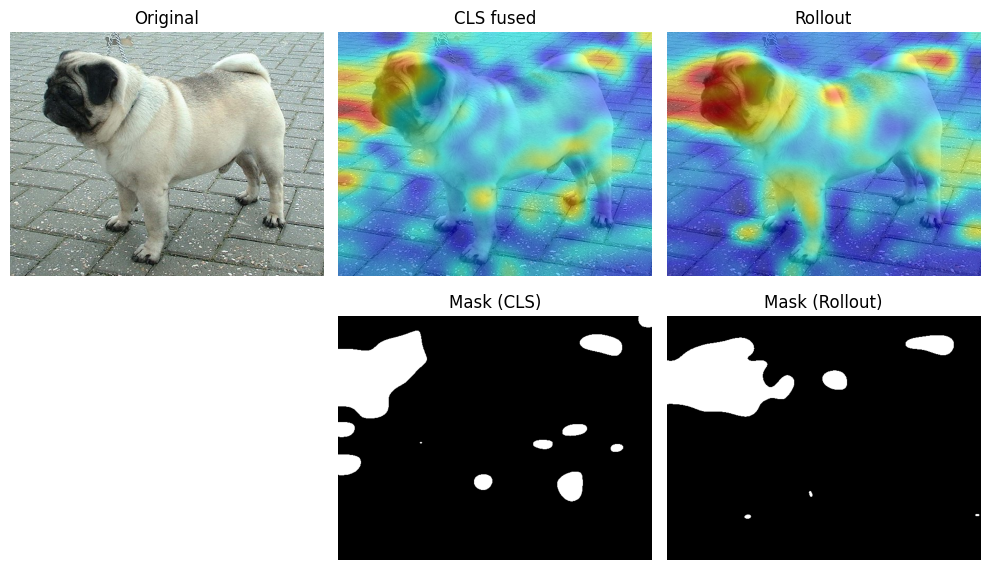

  Saved to: outputs/sample_00

=== Processing [2/7]: https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg


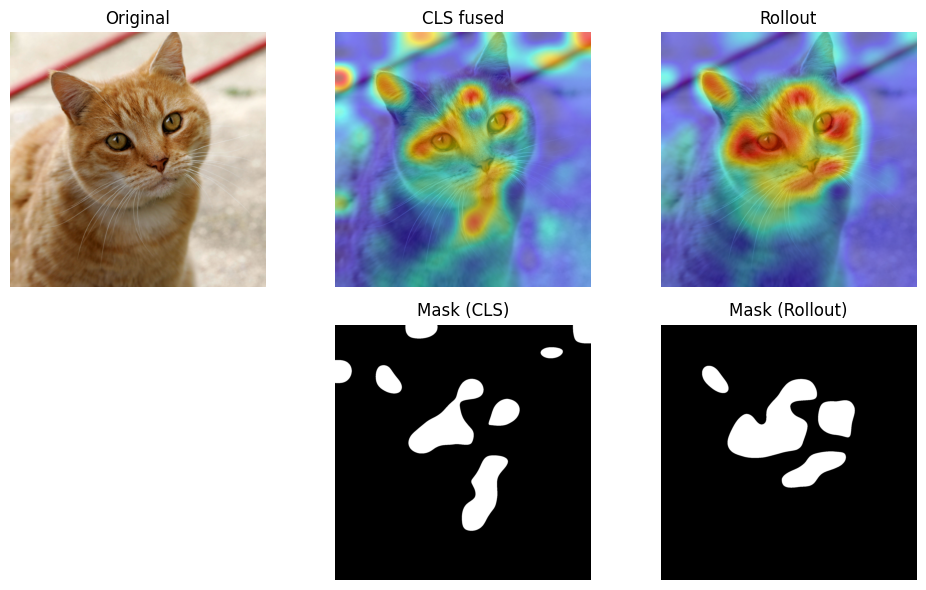

  Saved to: outputs/sample_01

=== Processing [3/7]: https://upload.wikimedia.org/wikipedia/commons/thumb/4/45/A_small_cup_of_coffee.JPG/640px-A_small_cup_of_coffee.JPG


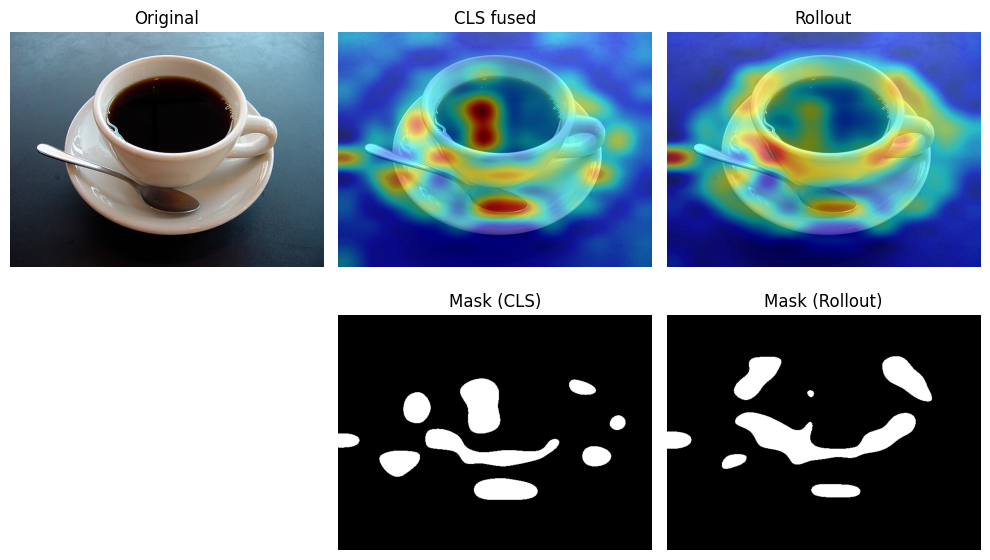

  Saved to: outputs/sample_02

=== Processing [4/7]: https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Palestinian_women_grinding_coffee_beans.jpg/640px-Palestinian_women_grinding_coffee_beans.jpg


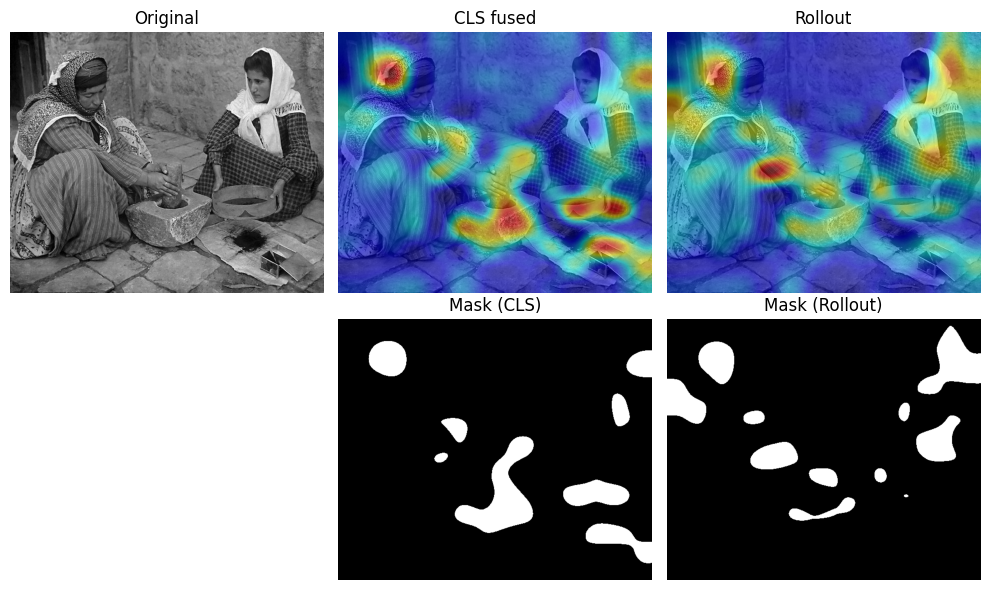

  Saved to: outputs/sample_03

=== Processing [5/7]: https://upload.wikimedia.org/wikipedia/commons/thumb/1/1e/Alaskan_Malamute_Biyaalsm-Attk.JPG/640px-Alaskan_Malamute_Biyaalsm-Attk.JPG


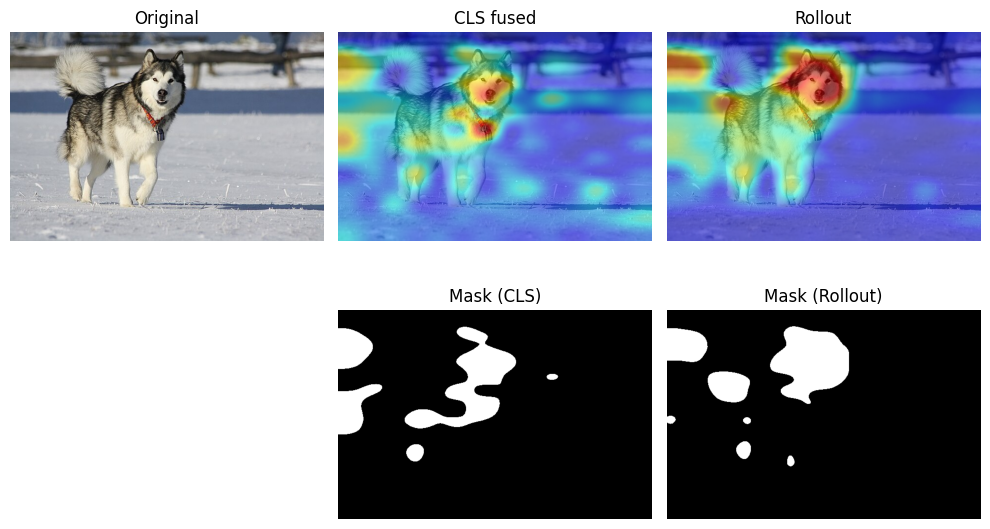

  Saved to: outputs/sample_04

=== Processing [6/7]: https://upload.wikimedia.org/wikipedia/commons/thumb/1/14/Monarch_butterfly_in_BBG_%2884684%29.jpg/640px-Monarch_butterfly_in_BBG_%2884684%29.jpg


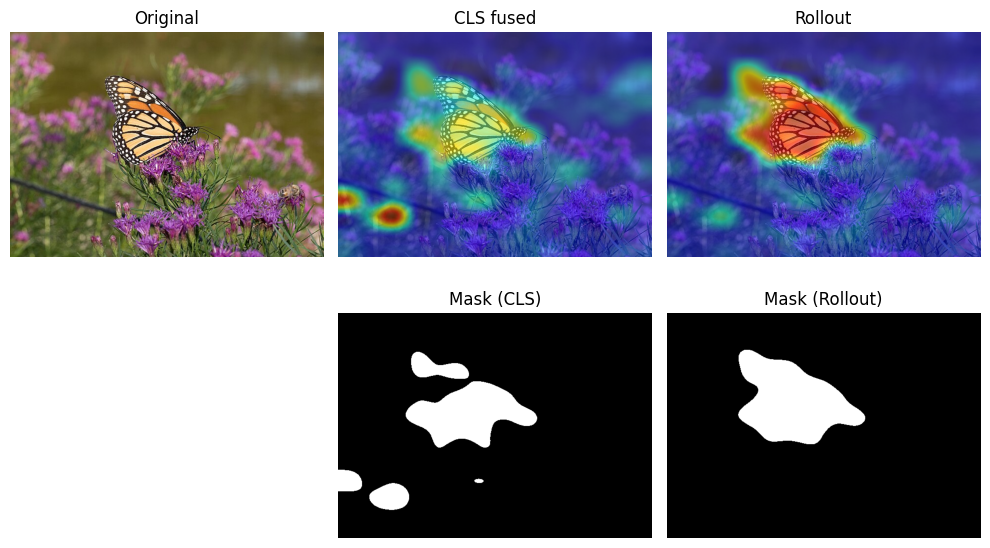

  Saved to: outputs/sample_05

=== Processing [7/7]: https://upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Cameleon_Tunisie.jpg/640px-Cameleon_Tunisie.jpg


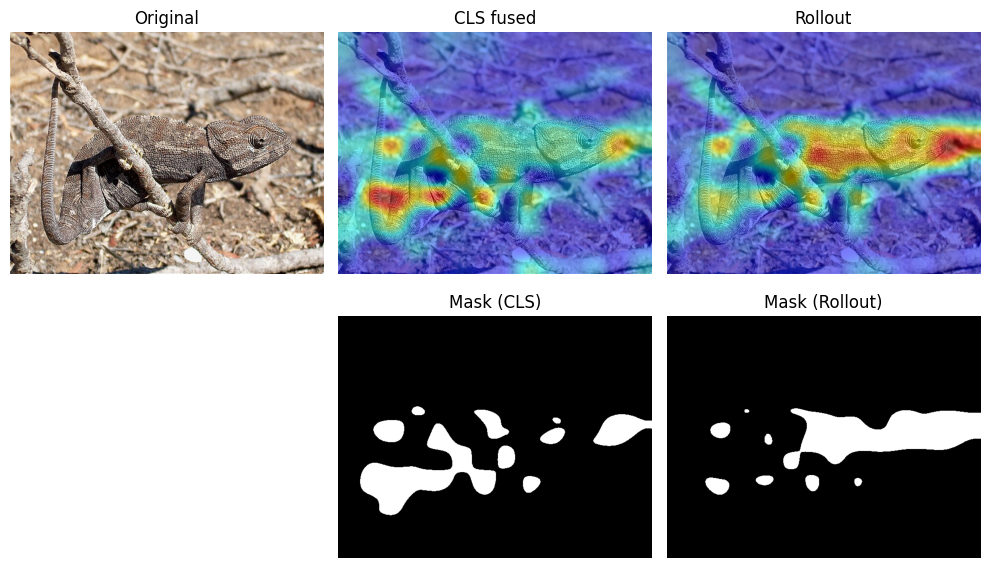

  Saved to: outputs/sample_06

All done. Results saved under: outputs


In [10]:
# Iterate over all EXAMPLE_URLS, generate and save outputs for each
from pathlib import Path

try:
    # Ensure hooks are attached
    if "register_timm_attention_hooks" in globals():
        try:
            clear_hooks()
            register_timm_attention_hooks(model)
        except Exception as e:
            print("Hook reattach warning:", e)

    base_out = Path(OUTPUT_DIR)
    base_out.mkdir(parents=True, exist_ok=True)

    for idx, url in enumerate(EXAMPLE_URLS):
        print(f"\n=== Processing [{idx+1}/{len(EXAMPLE_URLS)}]: {url}")
        try:
            img = load_image_from_url(url)
        except Exception as e:
            print("  Skip: failed to load image:", e)
            continue

        attn_layers, hw = forward_and_get_attentions(img)
        if not attn_layers:
            print("  Skip: no attention maps captured.")
            continue

        cls_maps = cls_last_layer_map(attn_layers)  # [H,S,S]
        cls_fused = head_fuse(cls_maps, mode=HEAD_FUSION)
        roll_map = attention_rollout(attn_layers, head_fusion=HEAD_FUSION)

        cls_resized = upsample_to_image(cls_fused, img.size[::-1])  # PIL size (W,H)
        roll_resized = upsample_to_image(roll_map, img.size[::-1])

        overlay_cls = overlay_heatmap(img, cls_resized, alpha=0.5)
        overlay_roll = overlay_heatmap(img, roll_resized, alpha=0.5)

        mask_cls = binary_mask_from_heat(cls_resized, percentile=THRESHOLD_PERCENTILE)
        mask_roll = binary_mask_from_heat(roll_resized, percentile=THRESHOLD_PERCENTILE)

        out_dir = base_out / f"sample_{idx:02d}"
        out_dir.mkdir(parents=True, exist_ok=True)

        cv2.imwrite(
            str(out_dir / "overlay_cls.jpg"),
            cv2.cvtColor(overlay_cls, cv2.COLOR_RGB2BGR),
        )
        cv2.imwrite(
            str(out_dir / "overlay_roll.jpg"),
            cv2.cvtColor(overlay_roll, cv2.COLOR_RGB2BGR),
        )
        cv2.imwrite(str(out_dir / "mask_cls.png"), mask_cls)
        cv2.imwrite(str(out_dir / "mask_roll.png"), mask_roll)

        # Optional: show a compact figure for quick visual check
        plt.figure(figsize=(10, 6))
        plt.subplot(2, 3, 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("Original")
        plt.subplot(2, 3, 2)
        plt.imshow(overlay_cls)
        plt.axis("off")
        plt.title("CLS fused")
        plt.subplot(2, 3, 3)
        plt.imshow(overlay_roll)
        plt.axis("off")
        plt.title("Rollout")
        plt.subplot(2, 3, 5)
        plt.imshow(mask_cls, cmap="gray")
        plt.axis("off")
        plt.title("Mask (CLS)")
        plt.subplot(2, 3, 6)
        plt.imshow(mask_roll, cmap="gray")
        plt.axis("off")
        plt.title("Mask (Rollout)")
        plt.tight_layout()
        plt.show()
        print("  Saved to:", out_dir)

    print("\nAll done. Results saved under:", base_out)
except Exception as e:
    print("Demo failed:", e)
    print("Tips: Re-run the hook patch and attention utilities if needed.")

## Upload Images (optional)

If you want to upload images, run this ***before*** the "Export HTML..." cell and wait for a few seconds to let the upload complete. 

In [14]:
# Upload images via Jupyter/Colab widget and extend the input list
try:
    import ipywidgets as widgets
    from IPython.display import display
    from google.colab import files as colab_files  # works only in Colab

    IN_COLAB = True
except Exception:
    IN_COLAB = False
    try:
        import ipywidgets as widgets
        from IPython.display import display
    except Exception as e:
        widgets = None
        print("ipywidgets not available; upload UI disabled.")

USER_IMAGE_PATHS = []  # paths saved locally

if IN_COLAB:
    # Colab upload
    print("Colab detected: choose images to upload...")
    uploaded = colab_files.upload()  # opens a file chooser
    for name, data in uploaded.items():
        with open(name, "wb") as f:
            f.write(data)
        USER_IMAGE_PATHS.append(name)
    print("Uploaded:", USER_IMAGE_PATHS)
else:
    # Jupyter upload widget (saves to current directory)
    if widgets is not None:
        uploader = widgets.FileUpload(accept="image/*", multiple=True)
        display(uploader)

        def _save_files(change):
            files = uploader.value
            saved = []
            # Handle ipywidgets 7.x (dict) and 8.x (tuple/list of dicts)
            if isinstance(files, dict):
                for fname, entries in files.items():
                    entries = (
                        entries if isinstance(entries, (list, tuple)) else [entries]
                    )
                    for entry in entries:
                        # entry may be a dict with 'content' or raw bytes
                        content = (
                            entry.get("content") if isinstance(entry, dict) else entry
                        )
                        if content is None:
                            continue
                        with open(fname, "wb") as f:
                            f.write(content)
                        if fname not in USER_IMAGE_PATHS:
                            USER_IMAGE_PATHS.append(fname)
                        saved.append(fname)
            else:
                # ipywidgets 8.x: tuple/list of dicts with {name, content, ...}
                for entry in files:
                    if not isinstance(entry, dict):
                        continue
                    fname = entry.get("name", "upload.bin")
                    content = entry.get("content", b"")
                    with open(fname, "wb") as f:
                        f.write(content)
                    if fname not in USER_IMAGE_PATHS:
                        USER_IMAGE_PATHS.append(fname)
                    saved.append(fname)
            print("Saved files:", saved)

        uploader.observe(_save_files, names="value")
    else:
        print(
            "Upload widget unavailable. You can place images in the notebook directory manually."
        )

FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

## Export HTML animations for all inputs

This cell creates a short HTML animation for each input image, showing fused CLS→patch heatmaps across layers as an overlay. I fuse heads per layer (mean or max), optionally downscale the source image for lighter files, and embed the frames using Matplotlib's JS backend (falls back automatically via the function).

In [ ]:
# Generate HTML animations (layers) for all example URLs and any uploaded images
from pathlib import Path
from urllib.parse import urlparse


def safe_slug_from_url(url: str) -> str:
    """Turn a URL into a safe filename-ish slug (no spaces or slashes)."""
    p = urlparse(url)
    base = Path(p.path).name or "image"
    return base.replace("/", "_").replace(" ", "_")


def _resize_keep_aspect(img: Image.Image, max_dim: int) -> Image.Image:
    """Resize an image to fit within max_dim while preserving aspect ratio."""
    w, h = img.size
    scale = 1.0 if max(w, h) <= max_dim else max_dim / float(max(w, h))
    if scale >= 1.0:
        return img
    new_size = (max(1, int(round(w * scale))), max(1, int(round(h * scale))))
    return img.resize(new_size, resample=Image.BICUBIC)


# Ensure a CLS→patch per-head helper exists (avoids dependency on removed utilities)
try:
    _cls_head_maps_from_layer
except NameError:

    def _cls_head_maps_from_layer(attn_layer_tensor, normalize="global"):
        """Extract per-head CLS→patch maps from a single layer `[1,H,N,N]`.

        Args:
            attn_layer_tensor (Tensor): One layer attention probs `[1,H,N,N]`.
            normalize (str|None): 'per-head', 'global', or None.
        Returns:
            Tensor: `[H,S,S]` maps.
        """
        A = attn_layer_tensor[0]  # [H,N,N]
        cls_to_tokens = A[:, 0, :]
        cls_to_patches = cls_to_tokens[:, 1:]
        P = cls_to_patches.shape[-1]
        S = int(math.sqrt(P))
        if S * S != P:
            raise ValueError(f"Patch count {P} not a perfect square.")
        maps = cls_to_patches.reshape(A.shape[0], S, S).float()  # [H,S,S]
        if normalize == "per-head":
            denom = maps.amax(dim=(-1, -2), keepdim=True) + 1e-6
            maps = maps / denom
        elif normalize == "global":
            mmax = maps.max() + 1e-6
            maps = maps / mmax
        elif normalize is None:
            pass
        else:
            raise ValueError("normalize must be one of: 'per-head', 'global', None")
        return maps


def export_html_layers_for_image(
    img: Image.Image,
    out_html: Path,
    fused_mode: str = HEAD_FUSION,
    fps: int = ANIM_FPS,
    sample_every: int = ANIM_SAMPLE_EVERY,
    max_dim: int = ANIM_MAX_DIM,
    embed_limit_mb: int = ANIM_EMBED_LIMIT_MB,
):
    """Export a single HTML animation of fused CLS heatmaps across layers.

    Steps:
      1) Optionally downscale the input image to `max_dim` (long side) for lighter output.
      2) Run the model to capture attention per layer.
      3) For sampled layers, compute CLS→patch per-head maps, fuse (mean/max), upsample
         to image size, and overlay on the (possibly downscaled) image.
      4) Animate frames and embed to an HTML file using Matplotlib's JS exporter.

    Args:
        img (PIL.Image.Image): Source image.
        out_html (Path): Destination HTML file path.
        fused_mode (str): 'mean' or 'max' for head fusion.
        fps (int): Frames per second.
        sample_every (int): Use every k-th layer.
        max_dim (int): Downscale longest side of image to this size.
        embed_limit_mb (int): Matplotlib animation embed limit (MB).
    """
    # Downscale input for smaller embedded animations
    img_small = _resize_keep_aspect(img, max_dim=max_dim)

    # Build fused maps per layer (global norm for consistent brightness)
    attn_layers, _ = forward_and_get_attentions(img)
    L = len(attn_layers)
    if L == 0:
        raise RuntimeError("No attention layers captured; cannot export animation.")
    fused_maps = []
    step = max(1, int(sample_every))
    for l in range(0, L, step):
        maps = _cls_head_maps_from_layer(attn_layers[l], normalize="global")
        fused = head_fuse(maps, mode=fused_mode)
        fused_maps.append(upsample_to_image(fused, img_small.size[::-1]))

    # Build frames as overlays
    frames = [overlay_heatmap(img_small, m, alpha=0.5) for m in fused_maps]
    if not frames:
        raise RuntimeError("No frames produced; check sample_every and layer count.")

    h, w, _ = frames[0].shape
    fig, ax = plt.subplots(figsize=(w / 100, h / 100), dpi=100)
    ax.axis("off")
    im = ax.imshow(frames[0])
    title = ax.set_title("Layer 0")

    import matplotlib as mpl
    import matplotlib.animation as animation

    # Raise embed limit (in MB)
    try:
        mpl.rcParams["animation.embed_limit"] = embed_limit_mb
    except Exception:
        pass

    def update(i):
        im.set_data(frames[i])
        title.set_text(f"Layer {i * step}")
        return [im, title]

    interval_ms = int(round(1000 / max(1, fps)))
    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=interval_ms, blit=True
    )
    html = ani.to_jshtml()
    out_html.parent.mkdir(parents=True, exist_ok=True)
    with open(out_html, "w", encoding="utf-8") as f:
        f.write(html)
    plt.close(fig)


# Build input list (example URLs + any uploaded local files)
all_inputs = []
all_inputs.extend(EXAMPLE_URLS)
all_inputs.extend([Path(p).as_posix() for p in USER_IMAGE_PATHS])

export_base = Path(OUTPUT_DIR) / "animations"
export_base.mkdir(parents=True, exist_ok=True)

# Export per input
for idx, src in enumerate(all_inputs):
    try:
        if src.startswith("http"):
            img = load_image_from_url(src)
            slug = safe_slug_from_url(src)
        else:
            img = load_image_from_path(src)
            slug = Path(src).stem
        out_html = export_base / f"{idx:02d}_{slug}.html"
        print(f"Exporting animation for {src} -> {out_html}")
        export_html_layers_for_image(img, out_html)
    except Exception as e:
        print(f"Failed to export animation for {src}:", e)
        continue
print("HTML animations saved to", export_base)

Exporting animation for https://upload.wikimedia.org/wikipedia/commons/9/9a/Pug_600.jpg -> outputs/animations/00_Pug_600.jpg.html
Exporting animation for https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg -> outputs/animations/01_Cat03.jpg.html
Exporting animation for https://upload.wikimedia.org/wikipedia/commons/thumb/4/45/A_small_cup_of_coffee.JPG/640px-A_small_cup_of_coffee.JPG -> outputs/animations/02_640px-A_small_cup_of_coffee.JPG.html
Exporting animation for https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Palestinian_women_grinding_coffee_beans.jpg/640px-Palestinian_women_grinding_coffee_beans.jpg -> outputs/animations/03_640px-Palestinian_women_grinding_coffee_beans.jpg.html
Exporting animation for https://upload.wikimedia.org/wikipedia/commons/thumb/1/1e/Alaskan_Malamute_Biyaalsm-Attk.JPG/640px-Alaskan_Malamute_Biyaalsm-Attk.JPG -> outputs/animations/04_640px-Alaskan_Malamute_Biyaalsm-Attk.JPG.html
Exporting animation for https://upload.wikimedia.org/wiki

## Commentary: Does DINO Attention Localize Objects Well?
- When it works: single salient object with clear boundaries; DINO often highlights the main subject (e.g., the dog).
- Failure cases: cluttered scenes, very small objects, unusual aspect ratios or heavy cropping.
- Rollout vs last-layer: rollout spreads attention across layers and can be more robust; last-layer may be sharper but head-dependent.
- Caveat: attention is not a definitive explanation; it’s a useful probe.